# Belediye Şikayet Sınıflandırma — BERTurk (tam donanımlı)


## 1. Import + seed + cihaz

In [1]:
import os, re, random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

# Tekrarlanabilirlik için sabit seed
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda


## 2. Veri yükleme + temizleme + etiketleme + bölme

In [3]:
# Veri: text + label sütunlu CSV (üreteçten gelen sentetik belediye verisi)
df = pd.read_csv("belediye_sikayetleri_tr.csv")
df = df.dropna(subset=["text", "label"])

# Türkçe-güvenli temizleme:
# İngilizce sürüm küçük harfe çevirip [^a-zA-Z] siliyordu -> Türkçe karakterleri yok eder.
# Burada SADECE fazla boşlukları sadeleştiriyoruz; büyük/küçük harf ve ç,ş,ğ,ı,ö,ü korunur.
# (Veri setindeki kasıtlı "gürültü" modeli daha sağlam yapsın diye bilerek bırakılıyor.)
def clean_text(t):
    t = str(t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df["text"] = df["text"].apply(clean_text)
df = df[df["text"].str.len() > 5]

# Etiketleri sayıya çevir
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])
NUM_LABELS = len(le.classes_)
print(f"{len(df)} örnek, {NUM_LABELS} kategori:")
print(list(le.classes_))

# Stratified bölme: her kategori train ve test'te dengeli temsil edilsin
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values, df["label_id"].values,
    test_size=0.2, random_state=42, stratify=df["label_id"]
)
print("Train:", len(X_train), "Test:", len(X_test))

1200 örnek, 8 kategori:
['Başıboş Hayvanlar', 'Gürültü ve Çevre Kirliliği', 'Park ve Yeşil Alan', 'Sokak Aydınlatması', 'Su ve Kanalizasyon', 'Toplu Ulaşım', 'Yol ve Kaldırım', 'Çöp ve Temizlik']
Train: 960 Test: 240


## 3. Model + class weights + kayıp fonksiyonu

In [4]:
MODEL_NAME = "dbmdz/bert-base-turkish-cased"   # BERTurk
# Tek modelle hem TR hem EN istersen: "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    id2label={i: c for i, c in enumerate(le.classes_)},
    label2id={c: i for i, c in enumerate(le.classes_)},
).to(device)

# Class weights: sınıflar dengesizse az olan sınıfa daha çok ağırlık verir.
# (Sentetik veri dengeli olsa bile genel pratik; gerçek veride çok işe yarar.)
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11040.27it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from

## 4. Dataset + DataLoader

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH = 16
train_loader = DataLoader(TextDataset(X_train, y_train, tokenizer), batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(TextDataset(X_test,  y_test,  tokenizer), batch_size=BATCH)

## 5. Optimizer + scheduler + early stopping + AMP

In [5]:
EPOCHS = 8
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),   # ilk %10 ısınma
    num_training_steps=total_steps)

class EarlyStopping:
    """Skor (F1) belirli sayıda epoch boyunca artmazsa eğitimi durdurur."""
    def __init__(self, patience=3):
        self.patience = patience; self.counter = 0
        self.best = 0.0; self.stop = False
    def step(self, score):
        if score > self.best:
            self.best = score; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stopper = EarlyStopping(patience=3)

# AMP yalnızca GPU'da aktif; CPU'da otomatik no-op olur (hata vermez).
use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler(enabled=use_amp)

## 6. Eğitim döngüsü (validation + best-save + early stop)

In [6]:
def evaluate(loader):
    model.eval(); preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            out = model(input_ids=ids, attention_mask=mask)
            p = torch.argmax(out.logits, dim=1)
            preds.extend(p.cpu().numpy()); trues.extend(batch["labels"].numpy())
    return np.array(trues), np.array(preds)

train_losses, val_accuracies, val_f1s = [], [], []
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train(); total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            out = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        scaler.step(optimizer); scaler.update()
        scheduler.step()
        total_loss += loss.item()

    true, preds = evaluate(test_loader)
    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average="weighted")
    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss); val_accuracies.append(acc); val_f1s.append(f1)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={avg_loss:.4f} | acc={acc:.4f} | f1={f1:.4f}")

    if f1 > best_f1:                       # en iyi modeli sakla
        best_f1 = f1
        model.save_pretrained("belediye-bert-tr")
        tokenizer.save_pretrained("belediye-bert-tr")
        print("  -> en iyi model kaydedildi")

    early_stopper.step(f1)
    if early_stopper.stop:
        print("EARLY STOPPING tetiklendi.")
        break

print(f"\nEn iyi F1: {best_f1:.4f}")

c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/8 | loss=2.1253 | acc=0.1542 | f1=0.1356


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


  -> en iyi model kaydedildi
Epoch 2/8 | loss=1.6266 | acc=0.8875 | f1=0.8842


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


...

  -> en iyi model kaydedildi
Epoch 5/8 | loss=0.0187 | acc=0.9917 | f1=0.9917
Epoch 6/8 | loss=0.0118 | acc=0.9958 | f1=0.9958


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.68s/it]


  -> en iyi model kaydedildi
Epoch 7/8 | loss=0.0071 | acc=1.0000 | f1=1.0000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


  -> en iyi model kaydedildi
Epoch 8/8 | loss=0.0064 | acc=0.9958 | f1=0.9958

En iyi F1: 1.0000


## 7. Final metrikler + classification report + confusion matrix

In [17]:
true, preds = evaluate(test_loader)
print("Accuracy :", accuracy_score(true, preds))
print("Precision:", precision_score(true, preds, average="weighted"))
print("Recall   :", recall_score(true, preds, average="weighted"))
print("F1 Score :", f1_score(true, preds, average="weighted"))
print("\n", classification_report(true, preds, target_names=le.classes_))

cm = confusion_matrix(true, preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix"); plt.xlabel("Tahmin"); plt.ylabel("Gerçek")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

NameError: name 'evaluate' is not defined

## 8. Eğitim grafikleri

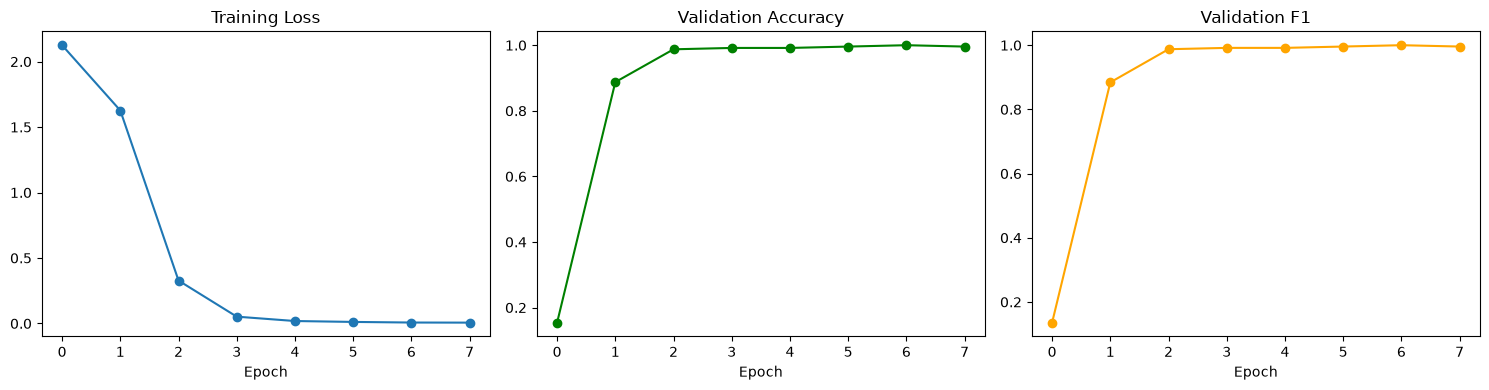

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(train_losses, marker="o"); ax[0].set_title("Training Loss"); ax[0].set_xlabel("Epoch")
ax[1].plot(val_accuracies, marker="o", color="green"); ax[1].set_title("Validation Accuracy"); ax[1].set_xlabel("Epoch")
ax[2].plot(val_f1s, marker="o", color="orange"); ax[2].set_title("Validation F1"); ax[2].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

## 9. Tek metin tahmini

In [10]:
def predict(text):
    model.eval()
    enc = tokenizer(clean_text(text), padding="max_length", truncation=True,
                    max_length=128, return_tensors="pt")
    ids = enc["input_ids"].to(device); mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        out = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits, dim=1)[0]
        pred = torch.argmax(probs).item()
    return le.classes_[pred], float(probs[pred])

for t in ["Sokak lambaları üç gündür yanmıyor",
          "çöpler toplanmadı her yer kokuyor",
          "otobüs saatinde gelmiyor hep geç kalıyoruz"]:
    etiket, guven = predict(t)
    print(f"{etiket} ({guven:.2f}) <- {t}")

Su ve Kanalizasyon (0.26) <- Sokak lambaları üç gündür yanmıyor
Su ve Kanalizasyon (0.23) <- çöpler toplanmadı her yer kokuyor
Su ve Kanalizasyon (0.22) <- otobüs saatinde gelmiyor hep geç kalıyoruz


## 10. Test arayüzü (Gradio) — notebook içinde açılır

In [8]:
import gradio as gr
import torch.nn.functional as F

def siniflandir(metin):
    if not metin or not metin.strip():
        return {}
    model.eval()
    enc = tokenizer(clean_text(metin), padding="max_length", truncation=True,
                    max_length=128, return_tensors="pt")
    ids = enc["input_ids"].to(device); mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        probs = F.softmax(model(input_ids=ids, attention_mask=mask).logits, dim=1)[0]
    return {le.classes_[i]: float(probs[i]) for i in range(len(le.classes_))}

ornekler = ["Sokağımızdaki çöpler üç gündür toplanmadı, leş gibi kokuyor.",
            "Mahallede sokak lambaları yanmıyor, akşam her yer karanlık.",
            "Yolun ortasında koca bir çukur var, araçlar zarar görüyor.",
            "Başıboş köpekler çocuklara havlıyor, korkuyoruz."]

gr.Interface(fn=siniflandir,
    inputs=gr.Textbox(lines=4, placeholder="Şikayetinizi yazın...", label="Belediye Şikayeti"),
    outputs=gr.Label(num_top_classes=5, label="Tahmin edilen kategori"),
    examples=ornekler, title="Belediye Şikayet Sınıflandırma (BERTurk)",
    flagging_mode="never").launch()   # arkadaşa link: .launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\KülKedisi\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY'

In [7]:
import re, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = "belediye-bert-tr"   # eğitimde kaydedilen klasör
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

def clean_text(t):
    return re.sub(r"\s+", " ", str(t)).strip()

def predict(text):
    enc = tokenizer(clean_text(text), padding="max_length", truncation=True,
                    max_length=128, return_tensors="pt")
    ids = enc["input_ids"].to(device); mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        probs = torch.softmax(model(input_ids=ids, attention_mask=mask).logits, dim=1)[0]
    pred = int(torch.argmax(probs))
    return model.config.id2label[pred], float(probs[pred])

print(predict("çöpler üç gündür toplanmadı her yer kokuyor"))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10335.36it/s]


('Çöp ve Temizlik', 0.9962776303291321)


In [18]:
print("model" in globals())
print("test_loader" in globals())
print("evaluate" in globals())

True
True
False


In [19]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            trues.extend(labels.cpu().numpy())

    return np.array(trues), np.array(preds)

true, preds = evaluate(test_loader)

print("Accuracy :", accuracy_score(true, preds))
print("Precision:", precision_score(true, preds, average="weighted"))
print("Recall   :", recall_score(true, preds, average="weighted"))
print("F1 Score :", f1_score(true, preds, average="weighted"))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
